#### NAMA : Tini Agustina
#### Nim : 4222301047

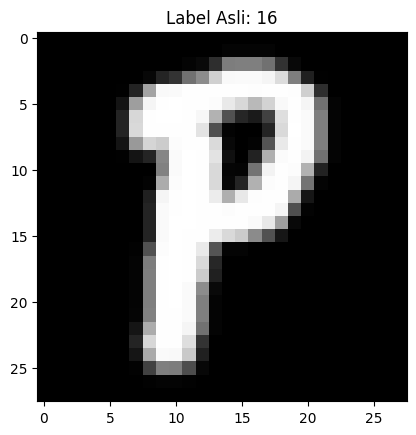

Mengekstraksi fitur HOG, mohon tunggu...
Memulai proses Grid Search SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Parameter SVM Terbaik: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Classification Report:
              precision    recall  f1-score   support

           1       0.65      0.85      0.74        20
           2       1.00      0.85      0.92        20
           3       0.84      0.80      0.82        20
           4       0.84      0.80      0.82        20
           5       0.76      0.80      0.78        20
           6       1.00      0.85      0.92        20
           7       0.74      0.85      0.79        20
           8       0.90      0.95      0.93        20
           9       0.44      0.40      0.42        20
          10       0.89      0.85      0.87        20
          11       0.94      0.80      0.86        20
          12       0.59      0.65      0.62        20
          13       0.83      0.95      0.88        20
          14  

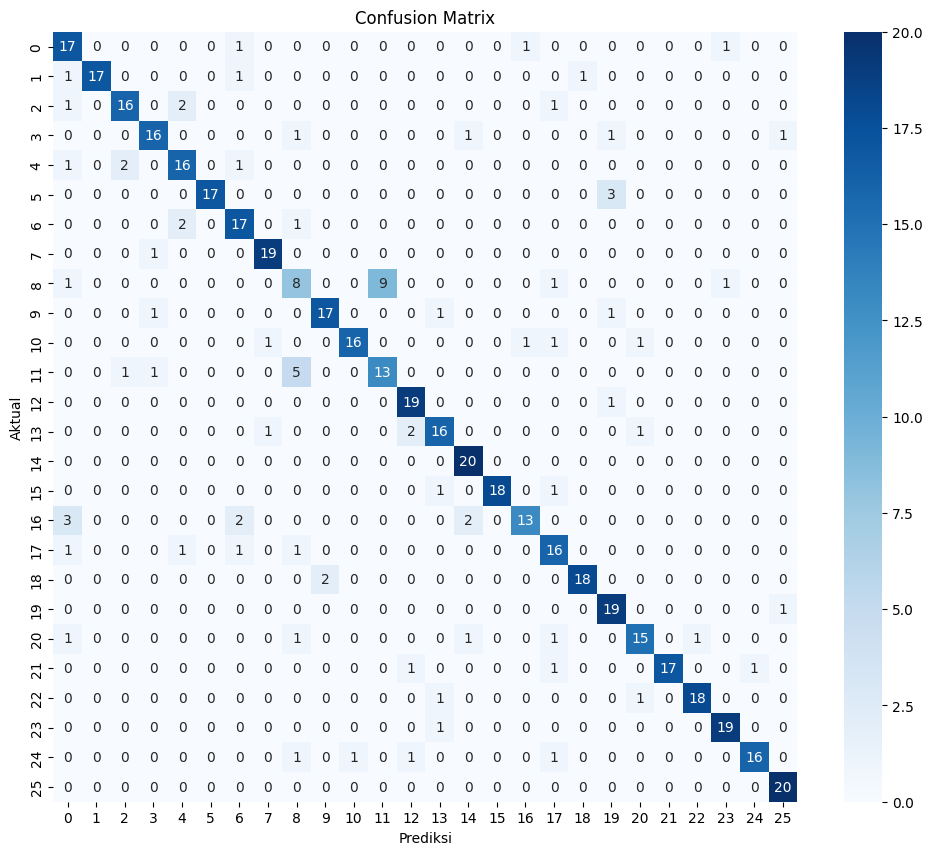

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, f1_score
from skimage.feature import hog
from sklearn.utils import shuffle

# 1. PERSIAPAN DATASET
data_path = 'emnist-letters-train.csv' 
dataset = pd.read_csv(data_path)

# Mengambil X (pixel) dan y (label/kelas)
# Asumsi: Kolom pertama adalah label (angka 1-26 mewakili A-Z)
y_full = dataset.iloc[:, 0].values
X_full = dataset.iloc[:, 1:].values

# Mengambil 100 sampel untuk masing-masing 26 kelas (total 2600 sampel)
X_balanced = []
y_balanced = []

for i in range(1, 27):
    # Cari index yang kelasnya = i
    idx = np.where(y_full == i)[0]
    # Ambil 100 sampel pertama dari kelas tersebut
    idx_sampled = idx[:100]
    
    X_balanced.extend(X_full[idx_sampled])
    y_balanced.extend(y_full[idx_sampled])

X_balanced = np.array(X_balanced)
y_balanced = np.array(y_balanced)

# Shuffle dataset
X_shuffled, y_shuffled = shuffle(X_balanced, y_balanced, random_state=42)

# Visualisasi satu contoh gambar (opsional, untuk memastikan data benar)
sample_img = X_shuffled[0].reshape(28, 28).T 
plt.imshow(sample_img, cmap='gray')
plt.title(f"Label Asli: {y_shuffled[0]}")
plt.show()

# 2. EKSTRAKSI FITUR (HOG)
def extract_hog_features(images):
    hog_features = []
    for img in images:
        img_2d = img.reshape(28, 28).T
        
        fd = hog(img_2d, 
                 orientations=9, 
                 pixels_per_cell=(4, 4), 
                 cells_per_block=(2, 2), 
                 visualize=False)
        hog_features.append(fd)
    return np.array(hog_features)

print("Mengekstraksi fitur HOG, mohon tunggu...")
X_features = extract_hog_features(X_shuffled)

# 3. SPLIT DATA (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_shuffled, test_size=0.20, stratify=y_shuffled, random_state=42)

# 4. KLASIFIKASI DENGAN SVM & GRID SEARCH
# Menyiapkan parameter yang mau diuji oleh Grid Search
param_grid = {
    'C': [0.1, 1, 10], 
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

print("Memulai proses Grid Search SVM...")
svm_model = SVC()
# cv=5 berarti 5-fold cross validation. 
# Jika ingin LOOCV murni untuk training, ganti cv=LeaveOneOut() (tetapi akan berjalan sangat lama)
grid = GridSearchCV(svm_model, param_grid, cv=5, verbose=2, n_jobs=-1) 
grid.fit(X_train, y_train)

print(f"Parameter SVM Terbaik: {grid.best_params_}")

# 5. EVALUASI PERFORMA
# Memprediksi data test
y_pred = grid.predict(X_test)

# Menampilkan hasil evaluasi (Accuracy, Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Menampilkan Confusion Matrix dengan visualisasi
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()


In [6]:
pip install scikit-image


Note: you may need to restart the kernel to use updated packages.Collecting scikit-image
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.8 MB 5.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.8/12.8 MB 4.4 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.8 MB 4.7 MB/s eta 0:00:03
   ------------ --------------------------- 3.9/12.8 MB 4.6 MB/s eta 0:00:02
   --------------- ------------------------ 5.0/12.8 MB 4.6 MB/s eta 0:00:02
   ------------------ --------------------- 5.8/12.8 MB 4.5 MB/s eta 0:00:02
   -------------------- ------------------- 6.6/12.8 MB 4.5 MB/s eta 0:00:02
   ----------------------- ---------------- 7.6/12.8 MB 4.4 MB/s eta 0:00:02
   --------------------------- ------------ 8.7/12.8 MB 4.5 MB/s eta 0:00:01
   ------------------------------ --------- 9.7/12.8 MB 4.5 MB/s eta 0:00:01
   -------------------------------- ------- 10.5/12.8 MB 4.5 MB/s eta 0


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Kesimpulan Proyek Klasifikasi EMNISTTujuan Utama: 
1. Proyek ini berhasil membangun sebuah program Machine Learning Pipeline untuk mengklasifikasikan karakter huruf tulisan tangan secara otomatis menggunakan dataset EMNIST.  
2. Pemrosesan Data: Untuk menjaga keseimbangan performa, program menggunakan 2.600 sampel data (tepat 100 sampel untuk masing-masing dari 26 kelas huruf). Data tersebut kemudian diacak dan dibagi dengan proporsi 80% untuk pelatihan model (training) dan 20% untuk pengujian (testing).  
3. Ekstraksi Fitur: Program tidak membaca gambar secara mentah, melainkan menggunakan metode ekstraksi fitur HOG (Histogram of Oriented Gradients). Metode ini terbukti efektif dalam mengubah pola visual garis dan lengkungan huruf menjadi representasi angka yang bisa dipahami oleh komputer.  
4. Klasifikasi dan Optimasi: Proses klasifikasi dilakukan menggunakan algoritma Support Vector Machine (SVM). Melalui penerapan teknik Grid Search dan Cross-Validation, program secara otomatis telah mencari dan menentukan hyperparameter SVM terbaik (meliputi parameter Kernel, nilai C, dan Gamma) untuk menghasilkan akurasi tertinggi.  
5. Evaluasi Hasil Akhir: Kinerja model telah dievaluasi dan diukur secara komprehensif menggunakan metrik Accuracy, Precision, Recall, dan F1-score, serta divisualisasikan dengan Confusion Matrix. Visualisasi ini membuktikan kemampuan model dalam membedakan ke-26 kelas huruf secara akurat.  